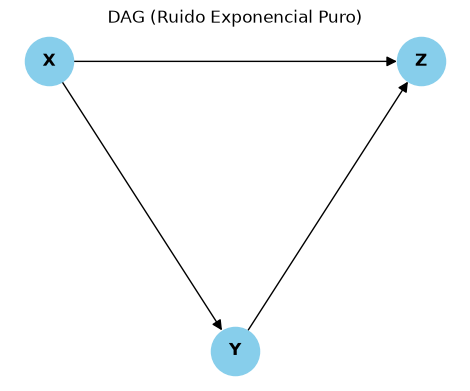


######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

INICIANDO EXPERIMENTO PARA N = 100
 -> Entrenando MSE para N=100 y semilla=42...
Using device: cpu
Early stopping at step 76
Using device: cpu
Early stopping at step 218
 -> Entrenando HSIC para N=100 y semilla=42...
Using device: cpu
Early stopping at step 279
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.1 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 185
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.2 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 172
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.3 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 168
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.4 para N=100 y semilla=42...
Using dev

,Experiment,Seed,Loss,Conf,Alpha,Beta,N,MSE Y,MAE Y,"HSIC(Y,X)",MSE Z,MAE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
1,1,42,hsic,HSIC,0.0,1.0,100,1.74711,0.87328,0.06303,7.25338,1.68128,0.30316,0.30829,0.00707,0.04185,0.80000
12,1,42,hsic,HSIC,0.0,1.0,300,2.51423,1.03921,0.05859,7.49361,1.49331,0.07818,0.20888,0.00231,0.07670,0.73333
23,1,42,hsic,HSIC,0.0,1.0,500,1.78873,0.86050,0.01467,16.81525,3.05353,0.05075,0.06609,0.00240,0.06302,0.75000
2,1,42,hybrid,HYBRID_ALPHA0.1_BETA0.9,0.1,0.9,100,1.23766,0.81458,0.07495,7.05680,1.67070,0.30378,0.30889,0.00720,0.04227,0.80000
3,1,42,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,1.24564,0.83110,0.08527,7.02843,1.66801,0.30336,0.30841,0.00727,0.04304,0.80000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,10,51,hybrid,HYBRID_ALPHA0.8_BETA0.2,0.8,0.2,500,1.07024,0.80624,0.08211,1.10618,0.76728,0.00720,0.00757,0.00123,0.02546,0.68000
329,10,51,hybrid,HYBRID_ALPHA0.9_BETA0.1,0.9,0.1,500,1.07429,0.80921,0.09098,1.11629,0.77139,0.01070,0.00909,0.00130,0.02532,0.66000
297,10,51,mse,MSE,1.0,0.0,100,1.38076,0.92955,0.21271,0.90897,0.74578,0.15336,0.04947,0.00431,0.04521,0.60000
308,10,51,mse,MSE,1.0,0.0,300,1.23193,0.78179,0.02218,1.26416,0.87926,0.09327,0.11009,0.00284,0.03279,0.58333


In [1]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Exponencial centrado (media 0, varianza escala**2)."""
    np.random.seed(seed)
    eps_X = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Y = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Z = np.random.exponential(scale=escala, size=num_samples) - escala
    
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Definimos los tamaños de muestra (N) que queremos auditar
valores_N_experimento = [100,300,500]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
semillas_experimento = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51]) # Ejecutar el experimento con 10 semillas distintas

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido Exponencial Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación de datos escalada al N actual
        data_triangle = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)
        
        datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
        num_muestras_eval = len(factual_eval_d)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)
                
            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico en el conjunto de evaluación de este N
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {
                'Experiment': experiment_id,
                'Seed': seed,
                'Loss': strategy_name,
                'Conf': conf_name,
                'Alpha': alpha_val,
                'Beta': beta_val,
                'N': N_actual
            }
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['Experiment', 'Seed', 'Loss', 'N', 'es_hibrido', 'Alpha', 'Beta'], ascending=[True, True, True, True, True, True, True])
# Reordenar columnas para mostrar primero experimento, semilla y función de pérdida
base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
other_cols = [c for c in df_final_multi_n.columns if c not in base_cols + ['es_hibrido']]
df_final_multi_n = df_final_multi_n[base_cols + other_cols]

print("\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA ---")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
ruta_archivo = os.path.join(carpeta_tablas, "aditivo_exponencial.csv")

# Crear la carpeta si no existe
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

# Guardar el DataFrame
df_final_multi_n.to_csv(ruta_archivo, index=False)

In [2]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACIÓN TÍPICA
# (Media ± Std para CADA combinación de Alpha/Beta a través de las 10 semillas)
# ==============================================================================
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)")
print("="*100)

# Identificar métricas numéricas (excluyendo metadatos)
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Procesar por tamaño de muestra (N) de forma independiente
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n\n{'#'*100}")
    print(f"# EXPERIMENTO: N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    # Agrupar por (Alpha, Beta) - esto captura cada combinación única
    resumen_por_config = []
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        # group_config contiene las 10 repeticiones (semillas) para esta combinación
        
        fila_resumen = {
            'Alpha': alpha_val,
            'Beta': beta_val,
            'Loss': group_config['Loss'].iloc[0],  # La Loss es la misma para esta combinación
            'Conf': group_config['Conf'].iloc[0],  # Nombre de la configuración
            'Num_Seeds': len(group_config)  # Debe ser 10
        }
        
        # Para cada métrica, calcular media y std de las 10 semillas
        for metrica in metricas_numericas:
            media_metrica = group_config[metrica].mean()
            std_metrica = group_config[metrica].std()
            # Guardar como valores separados para CSV
            fila_resumen[f'{metrica}_mean'] = round(media_metrica, 5)
            fila_resumen[f'{metrica}_std'] = round(std_metrica, 5)
        
        resumen_por_config.append(fila_resumen)
    
    # Convertir a DataFrame
    df_resumen_n = pd.DataFrame(resumen_por_config)
    
    # Ordenar por Loss (mse, hsic, hybrid) y luego por Alpha descendente
    orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
    df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
    df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
    df_resumen_n = df_resumen_n.drop('loss_order', axis=1)
    
    print(f"Tabla resumen para N={n_val}:\n")
    display(df_resumen_n)
    
    # Guardar cada tabla N en un CSV separado
    ruta_resumen_n = os.path.join("tablas", f"resumen_n_{n_val}_aditivo_exponencial.csv")
    if not os.path.exists("tablas"):
        os.makedirs("tablas")
    df_resumen_n.to_csv(ruta_resumen_n, index=False)
    print(f"\n✓ Tabla resumen guardada en: {ruta_resumen_n}\n")

# Crear también una tabla consolidada con formato legible "media ± std"
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media ± Std para cada métrica")
print(f"{'='*100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n{'#'*100}")
    print(f"# N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        conf_name = group_config['Conf'].iloc[0]
        loss_name = group_config['Loss'].iloc[0]
        
        print(f"\n{'-'*100}")
        print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, Loss={loss_name} | Seeds: {len(group_config)}")
        print(f"{'-'*100}")
        
        resumen_row = {}
        for metrica in metricas_numericas:
            media = group_config[metrica].mean()
            std = group_config[metrica].std()
            resumen_row[metrica] = f"{media:.5f} ± {std:.5f}"
        
        df_readable = pd.DataFrame([resumen_row]).T
        df_readable.columns = ['Media ± Std']
        display(df_readable)


TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)


####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS
####################################################################################################

Tabla resumen para N=100:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,2.11603,0.72144,1.02934,0.12412,0.23053,...,0.13778,0.04379,0.19000,0.15190,0.00519,0.00096,0.07445,0.04347,0.675,0.09501
0,0.0,1.0,hsic,HSIC,10,2.43700,1.10819,1.01441,0.23327,0.15773,...,0.23629,0.11375,0.39205,0.17144,0.00671,0.00141,0.11488,0.07148,0.685,0.11559
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,2.04346,0.77227,1.01276,0.13155,0.19849,...,0.11828,0.05485,0.16990,0.15983,0.00526,0.00068,0.06872,0.04007,0.655,0.09560
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,1.82455,0.86139,0.94882,0.14838,0.17022,...,0.10242,0.03751,0.14094,0.11120,0.00477,0.00163,0.06734,0.03289,0.660,0.08097
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,1.77552,0.88297,0.93830,0.15235,0.15066,...,0.09979,0.04069,0.14853,0.10845,0.00493,0.00164,0.06688,0.03399,0.675,0.08250
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,1.77432,0.87373,0.92754,0.15931,0.15237,...,0.10932,0.05457,0.15707,0.10183,0.00452,0.00142,0.06774,0.03600,0.635,0.06687
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,1.73348,0.90659,0.91974,0.17421,0.14664,...,0.12166,0.06017,0.19329,0.13749,0.00446,0.00146,0.07027,0.04113,0.670,0.11595
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,1.77234,0.90559,0.92591,0.17488,0.13608,...,0.13824,0.07098,0.19403,0.14377,0.00445,0.00132,0.06983,0.04212,0.680,0.12293
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,1.71439,0.88940,0.91484,0.17941,0.12233,...,0.16367,0.08916,0.22000,0.14484,0.00478,0.00155,0.06613,0.03822,0.660,0.11972
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,1.84998,0.80316,0.94710,0.14556,0.15809,...,0.17013,0.09085,0.21678,0.15286,0.00531,0.00144,0.06983,0.03578,0.650,0.12247



✓ Tabla resumen guardada en: tablas\resumen_n_100_aditivo_exponencial.csv



####################################################################################################
# EXPERIMENTO: N = 300 MUESTRAS
####################################################################################################

Tabla resumen para N=300:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,1.30750,0.34057,0.81359,0.05373,0.04586,...,0.07015,0.02899,0.09391,0.07255,0.00283,0.00076,0.04744,0.01732,0.65500,0.05155
0,0.0,1.0,hsic,HSIC,10,2.19537,0.91707,0.94645,0.15468,0.04822,...,0.15177,0.04479,0.26876,0.10229,0.00452,0.00155,0.15748,0.07503,0.77667,0.06146
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,1.28271,0.35908,0.80720,0.06320,0.03414,...,0.05387,0.02742,0.08220,0.06793,0.00282,0.00088,0.04403,0.01648,0.64667,0.04500
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,1.28108,0.34906,0.80550,0.06200,0.03123,...,0.04721,0.02480,0.07646,0.06682,0.00273,0.00084,0.04290,0.01650,0.65000,0.03239
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,1.27287,0.34162,0.80033,0.05472,0.03217,...,0.04753,0.02157,0.08154,0.06451,0.00304,0.00104,0.04299,0.01645,0.64167,0.04730
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,1.26768,0.33134,0.79761,0.05048,0.03137,...,0.04206,0.01767,0.07790,0.05745,0.00308,0.00100,0.04274,0.01620,0.65000,0.04231
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,1.26980,0.33342,0.79648,0.05045,0.03068,...,0.03941,0.01375,0.07480,0.05327,0.00312,0.00105,0.04164,0.01657,0.64333,0.04919
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,1.28763,0.38035,0.79852,0.05059,0.03082,...,0.03435,0.01392,0.07135,0.05211,0.00300,0.00102,0.04049,0.01618,0.63667,0.05375
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,1.27816,0.35455,0.79827,0.04772,0.02986,...,0.03314,0.00913,0.06444,0.04227,0.00304,0.00121,0.03941,0.01495,0.63333,0.03425
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,1.24830,0.26021,0.79651,0.03786,0.03064,...,0.03245,0.00850,0.06592,0.04575,0.00303,0.00120,0.04008,0.01676,0.63167,0.04336



✓ Tabla resumen guardada en: tablas\resumen_n_300_aditivo_exponencial.csv



####################################################################################################
# EXPERIMENTO: N = 500 MUESTRAS
####################################################################################################

Tabla resumen para N=500:



...

,Media ± Std
MSE Y,1.76300 ± 1.57798
MAE Y,0.79235 ± 0.06739
"HSIC(Y,X)",0.02562 ± 0.02290
MSE Z,1.81236 ± 1.15221
MAE Z,0.91965 ± 0.14494
"HSIC(Z,X)",0.04321 ± 0.03123
"HSIC(Z,Y)",0.08363 ± 0.07976
dHSIC Total,0.00217 ± 0.00110
MMD,0.03013 ± 0.00952
RF Acc,0.71000 ± 0.04216



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.94867 ± 1.80383
MAE Y,0.79728 ± 0.06982
"HSIC(Y,X)",0.02788 ± 0.02585
MSE Z,1.62559 ± 0.42929
MAE Z,0.90849 ± 0.11403
"HSIC(Z,X)",0.04741 ± 0.03256
"HSIC(Z,Y)",0.08508 ± 0.08579
dHSIC Total,0.00196 ± 0.00097
MMD,0.02917 ± 0.00536
RF Acc,0.71100 ± 0.04458



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,1.86427 ± 1.58726
MAE Y,0.79666 ± 0.06627
"HSIC(Y,X)",0.03103 ± 0.02947
MSE Z,1.64659 ± 0.41771
MAE Z,0.91608 ± 0.11535
"HSIC(Z,X)",0.06037 ± 0.03568
"HSIC(Z,Y)",0.09329 ± 0.08715
dHSIC Total,0.00206 ± 0.00093
MMD,0.03079 ± 0.00481
RF Acc,0.71000 ± 0.02906



VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA
(Línea = Media | Área sombreada = Media ± Desviación Típica)
(Cada color = un tamaño de muestra N diferente)

✓ Gráfica consolidada guardada: plots\bandplot_todas_N_aditivo_exponencial.png



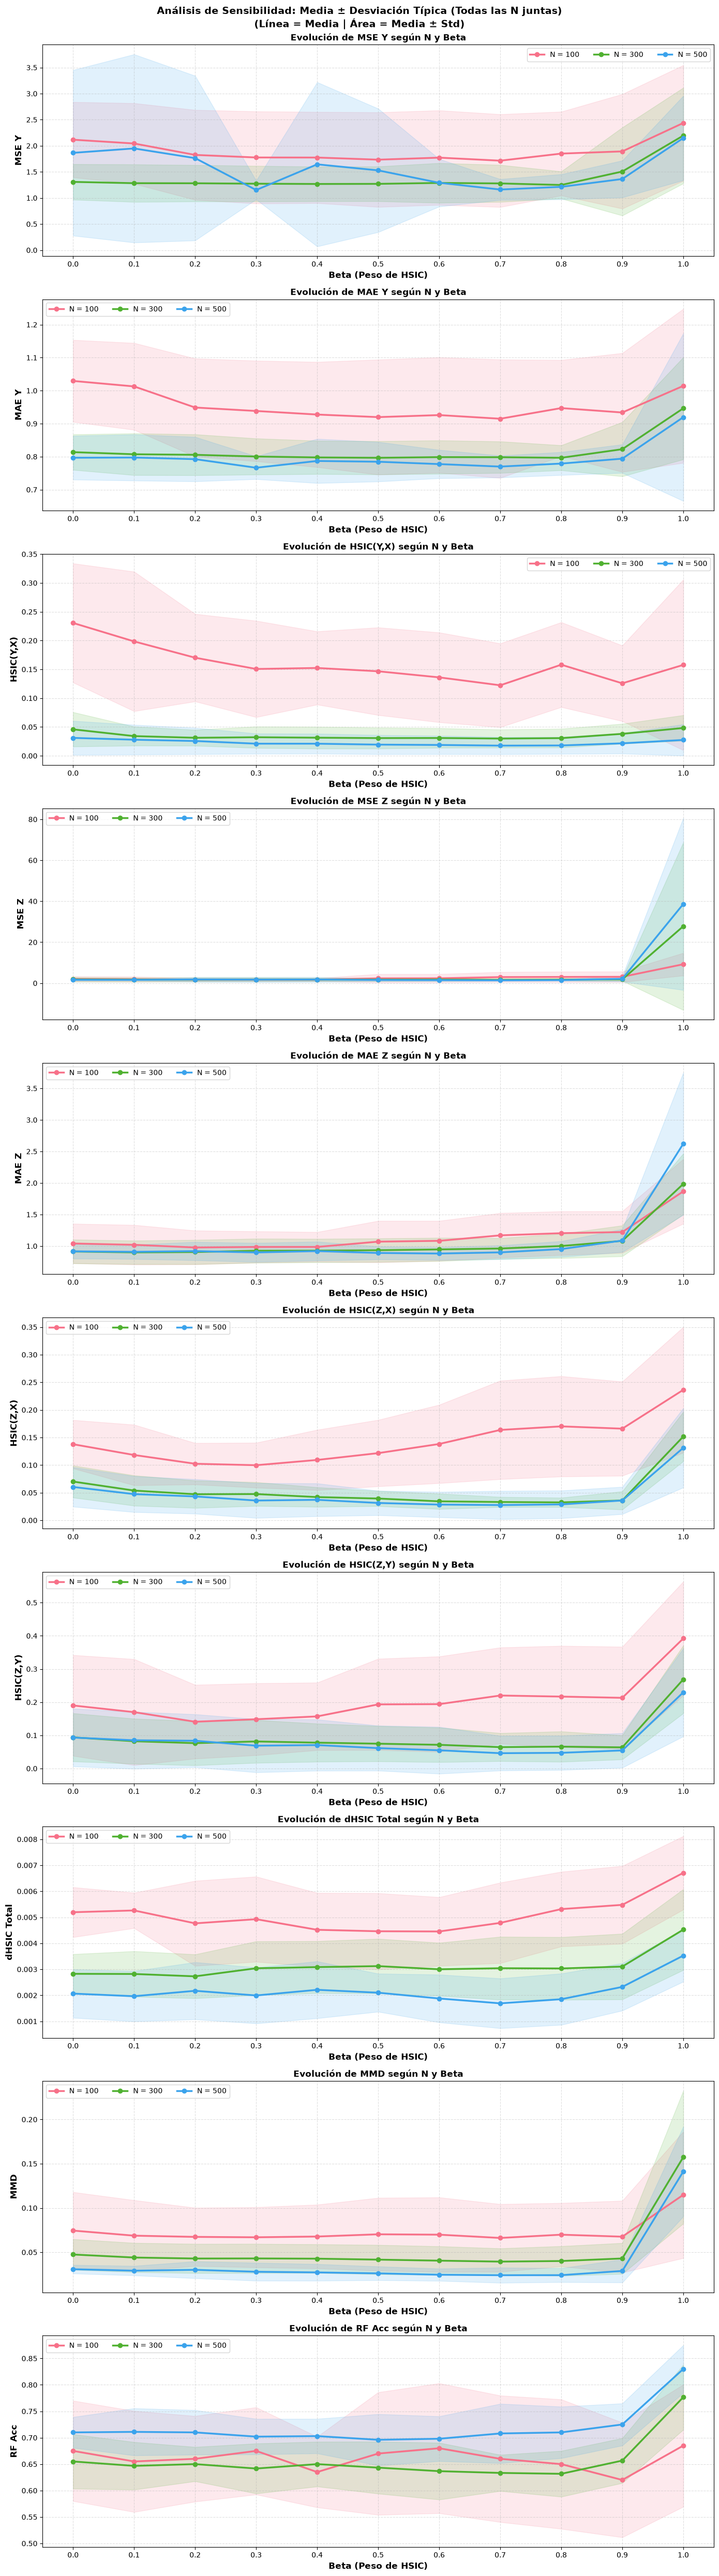

✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)


In [3]:
# ==============================================================================
# PASO 7: VISUALIZACIÓN CON MEDIA ± DESVIACIÓN TÍPICA (BAND PLOTS)
# Todas las N en una misma gráfica, organizadas por Beta
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA")
print("(Línea = Media | Área sombreada = Media ± Desviación Típica)")
print("(Cada color = un tamaño de muestra N diferente)")
print("="*100 + "\n")

# Identificar métricas numéricas
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_para_plot = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Crear tabla resumen GLOBAL (todos los N)
resumen_global = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
        row = {'N': n_val, 'Alpha': alpha, 'Beta': beta, 'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
        for metrica in metricas_para_plot:
            row[f'{metrica}_mean'] = group[metrica].mean()
            row[f'{metrica}_std'] = group[metrica].std()
        resumen_global.append(row)

df_global = pd.DataFrame(resumen_global)

# Paleta de colores por N
lista_n = sorted(df_global['N'].unique())
colores_n = sns.color_palette("husl", len(lista_n))
paleta_n = dict(zip(lista_n, colores_n))

# Configurar figura con subgráficos (uno por métrica)
num_plots = len(metricas_para_plot)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

fig.suptitle('Análisis de Sensibilidad: Media ± Desviación Típica (Todas las N juntas)\n(Línea = Media | Área = Media ± Std)', 
             fontsize=14, fontweight='bold', y=0.995)

# Para cada métrica
for idx, metrica in enumerate(metricas_para_plot):
    ax = axes[idx]
    
    # Para cada N, graficar una línea
    for n_val in sorted(df_global['N'].unique()):
        df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
        
        # Extraer valores de media y std
        x = df_n_data['Beta'].values
        y_mean = df_n_data[f'{metrica}_mean'].values
        y_std = df_n_data[f'{metrica}_std'].values
        
        # Calcular límites superiores e inferiores
        y_upper = y_mean + y_std
        y_lower = y_mean - y_std
        
        # Graficar: línea para media y área para std
        color = paleta_n[n_val]
        ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}', 
               color=color, markersize=6)
        ax.fill_between(x, y_lower, y_upper, alpha=0.15, color=color)
    
    # Estética
    ax.set_xlabel('Beta (Peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Evolución de {metrica} según N y Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=10, ncol=3)
    ax.set_xlim(-0.05, 1.05)
    
    # Establecer ticks en X
    ax.set_xticks(sorted(df_global['Beta'].unique()))

plt.tight_layout()

# Guardar figura
if not os.path.exists('plots'):
    os.makedirs('plots')

ruta_plot = os.path.join('plots', 'bandplot_todas_N_aditivo_exponencial.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica consolidada guardada: {ruta_plot}\n")
plt.show()

print(f"✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)")